In [2]:
from sklearn.metrics import mean_squared_error as mse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# creating the sample dataset
experience = [1.2,1.5,1.9,2.2,2.4,2.5,2.8,3.1,3.3,3.7,4.2,4.4]
salary = [1.7,2.4,2.3,3.1,3.7,4.2,4.4,6.1,5.4,5.7,6.4,6.2]
data = pd.DataFrame({ "salary" : salary, "experience" : experience })
print(data.head())

   salary  experience
0     1.7         1.2
1     2.4         1.5
2     2.3         1.9
3     3.1         2.2
4     3.7         2.4


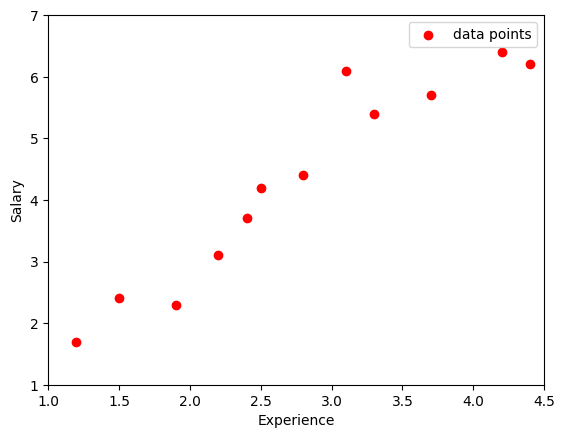

In [4]:
# plotting the data

plt.scatter(data.experience, data.salary, color = 'red', label = 'data points')
plt.xlim(1,4.5)
plt.ylim(1,7)
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.legend()

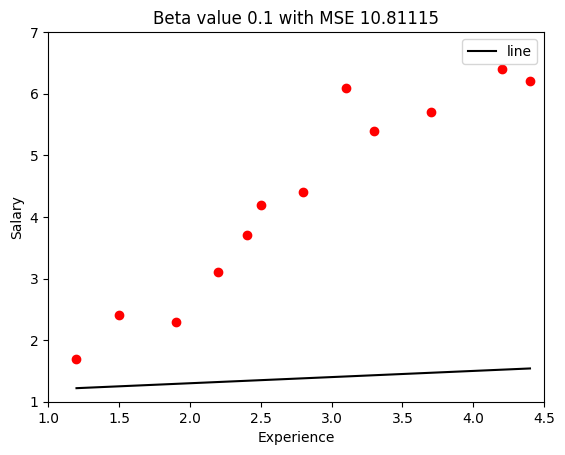

In [5]:
# making lines for different Values of Beta 0.1, 0.8, 1.5
beta = 0.1

# keeping intercept constant
b = 1.1

# to store predicted points
line1 = []

# generating predictions for every data point
for i in range(len(data)):
    line1.append(data.experience[i]*beta + b)

# Plotting the line
plt.scatter(data.experience, data.salary, color = 'red')
plt.plot(data.experience, line1, color = 'black', label = 'line')
plt.xlim(1,4.5)
plt.ylim(1,7)
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.legend()

MSE = mse(data.salary, line1)

plt.title("Beta value "+str(beta)+" with MSE "+ str(MSE))

MSE = mse(data.salary, line1)

In [6]:
MSE

10.81115

In [11]:
from sklearn.metrics import mean_squared_error as mse # Assuming you use sklearn

def Error(Beta, data):
    # b is constant
    b = 1.1
    salary = []
    experience = data.experience

    # Loop to calculate predict salary variables
    for i in range(len(data.experience)):
        tmp = data.experience[i] * Beta + b
        salary.append(tmp)

    # Calculate MSE
    MSE = mse(data.salary, salary)
    return MSE

In [12]:
# Range of slopes from 0 to 1.5 with increment of 0.01

slope = [i/100 for i in range(0,150)]
Cost = []
for i in slope:
    cost = Error( Beta = i, data = data)
    Cost.append(cost)

In [14]:
# Arranging in DataFrame

Cost_table = pd.DataFrame({
'Beta' : slope,
'Cost' : Cost
})

Cost_table.head()

,Beta,Cost
0,0.00,12.791667
1,0.01,12.585876
2,0.02,12.381806
3,0.03,12.179455
4,0.04,11.978824


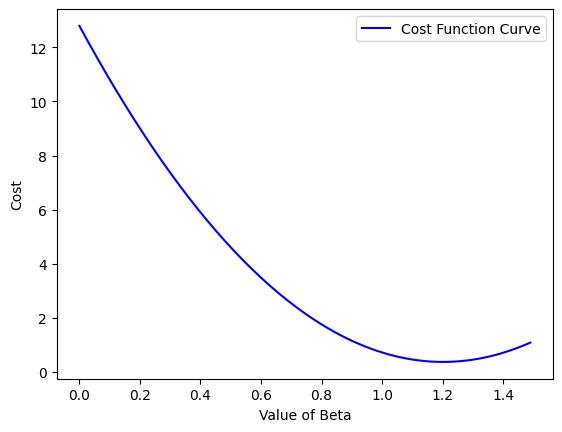

In [15]:
# plotting the cost values corresponding to every value of Beta

plt.plot(Cost_table.Beta, Cost_table.Cost, color = 'blue', label = 'Cost Function Curve')
plt.xlabel('Value of Beta')
plt.ylabel('Cost')
plt.legend()

----------------------------------------
SECTION 1: BASIC CALCULATION
----------------------------------------
   Actual ($k)  Predicted ($k)  Error (Diff)  Squared Error
0          200             210           -10            100
1          250             240            10            100
2          300             320           -20            400
3          350             340            10            100
4          400             430           -30            900

Calculations:
Sum of Squared Errors (SSE): 1600
Mean Squared Error (MSE):    320.00 (Units: $k squared)
Root Mean Sq Error (RMSE):   17.89 (Units: $k)
----------------------------------------

SECTION 2: SENSITIVITY TO OUTLIERS
----------------------------------------
Original MSE: 320.00  ->  With Outlier: 15266.67 (Increased by 47.7x)
Original RMSE: 17.89 ->  With Outlier: 123.56 (Increased by 6.9x)
Notice how MSE explodes much more dramatically than RMSE relative to its scale.
----------------------------------------


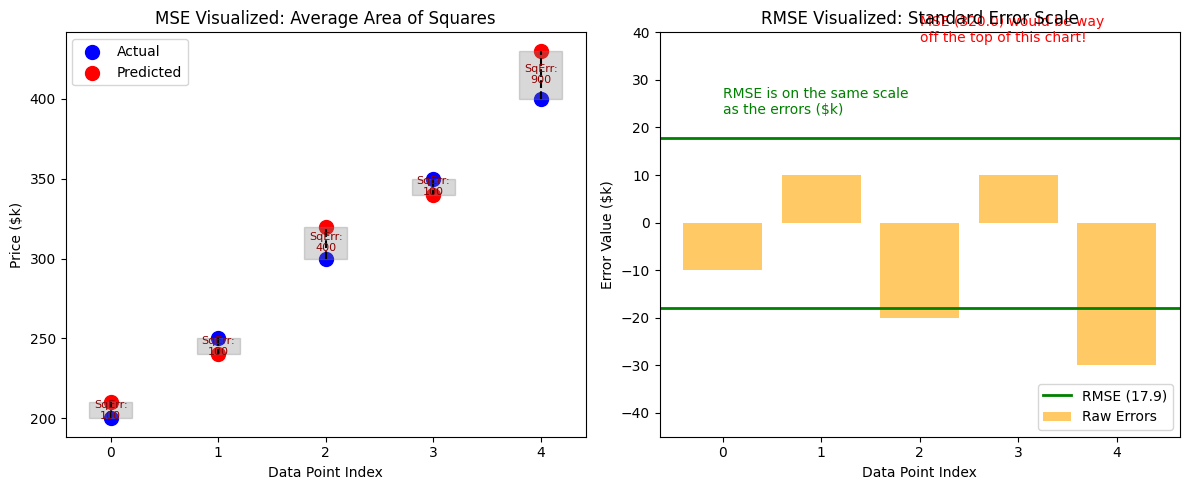

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def mse_vs_rmse_demo():
    # 1. Setup Synthetic Data
    # Imagine we are predicting house prices (in $1000s)
    actual_prices = np.array([200, 250, 300, 350, 400])
    predicted_prices = np.array([210, 240, 320, 340, 430])

    # 2. Calculate Differences (Errors)
    errors = actual_prices - predicted_prices
    squared_errors = errors ** 2

    # 3. Calculate MSE and RMSE
    mse_val = np.mean(squared_errors)
    rmse_val = np.sqrt(mse_val)

    # --- SECTION 1: Basic Comparison ---
    print("-" * 40)
    print("SECTION 1: BASIC CALCULATION")
    print("-" * 40)
    df = pd.DataFrame({
        'Actual ($k)': actual_prices,
        'Predicted ($k)': predicted_prices,
        'Error (Diff)': errors,
        'Squared Error': squared_errors
    })
    print(df)
    print("\nCalculations:")
    print(f"Sum of Squared Errors (SSE): {np.sum(squared_errors)}")
    print(f"Mean Squared Error (MSE):    {mse_val:.2f} (Units: $k squared)")
    print(f"Root Mean Sq Error (RMSE):   {rmse_val:.2f} (Units: $k)")
    print("-" * 40)

    # --- SECTION 2: The "Outlier" Effect ---
    # Let's introduce one bad prediction (an outlier)
    actual_outlier = np.append(actual_prices, 500)
    pred_outlier = np.append(predicted_prices, 800) # Massive error of 300

    errors_out = actual_outlier - pred_outlier
    mse_out = np.mean(errors_out ** 2)
    rmse_out = np.sqrt(mse_out)

    print("\nSECTION 2: SENSITIVITY TO OUTLIERS")
    print("-" * 40)
    print(f"Original MSE: {mse_val:.2f}  ->  With Outlier: {mse_out:.2f} (Increased by {mse_out/mse_val:.1f}x)")
    print(f"Original RMSE: {rmse_val:.2f} ->  With Outlier: {rmse_out:.2f} (Increased by {rmse_out/rmse_val:.1f}x)")
    print("Notice how MSE explodes much more dramatically than RMSE relative to its scale.")
    print("-" * 40)

    # --- SECTION 3: Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Visualizing MSE (Areas of Squares)
    ax1.set_title("MSE Visualized: Average Area of Squares")
    ax1.scatter(np.arange(len(actual_prices)), actual_prices, color='blue', label='Actual', s=100)
    ax1.scatter(np.arange(len(predicted_prices)), predicted_prices, color='red', label='Predicted', s=100)

    # Draw squares to represent MSE
    for i, (act, pred) in enumerate(zip(actual_prices, predicted_prices)):
        diff = abs(act - pred)
        # Draw a square patch centered on the x-value
        rect = plt.Rectangle((i - 0.2, min(act, pred)), 0.4, diff, color='gray', alpha=0.3)
        ax1.add_patch(rect)
        ax1.plot([i, i], [act, pred], color='black', linestyle='--')
        ax1.text(i, (act+pred)/2, f"SqErr:\n{diff**2}", ha='center', va='center', fontsize=8, color='darkred')

    ax1.set_xticks(np.arange(len(actual_prices)))
    ax1.set_xlabel("Data Point Index")
    ax1.set_ylabel("Price ($k)")
    ax1.legend()

    # Plot 2: Visualizing RMSE (Scale Comparison)
    ax2.set_title("RMSE Visualized: Standard Error Scale")

    # Plot errors as bars
    ax2.bar(np.arange(len(errors)), errors, color='orange', alpha=0.6, label='Raw Errors')

    # Plot RMSE and MSE levels
    ax2.axhline(y=rmse_val, color='green', linestyle='-', linewidth=2, label=f'RMSE ({rmse_val:.1f})')
    ax2.axhline(y=-rmse_val, color='green', linestyle='-', linewidth=2)

    # Attempt to plot MSE on the same graph usually fails because the scale is too big
    # We just annotate it to show the difference
    ax2.text(0, rmse_val + 5, "RMSE is on the same scale\nas the errors ($k)", color='green')
    ax2.text(2, rmse_val + 20, f"MSE ({mse_val:.1f}) would be way\noff the top of this chart!", color='red', fontsize=10)

    ax2.set_xlabel("Data Point Index")
    ax2.set_ylabel("Error Value ($k)")
    ax2.legend(loc='lower right')
    ax2.set_ylim(min(errors)*1.5, max(errors)*4) # Make room for text

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    mse_vs_rmse_demo()

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, SGDRegressor, HuberRegressor, QuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [18]:
# 1. Load and Prepare Data
print("Loading California Housing Dataset...")
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

Loading California Housing Dataset...


In [20]:
# We'll use just one feature 'MedInc' (Median Income) to make visualization easy (2D plots)
X_simple = X[['MedInc']].values
y_simple = y

In [21]:
np.random.seed(42)
outlier_indices = np.random.choice(len(y), 50, replace=False)
y_simple[outlier_indices] = 10.0

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Data Loaded. Artificial outliers added to simulate real-world noise.
------------------------------
Training MSE Model (Linear Regression)...
MSE Model Coefficient: 0.80
Training MAE Model (SGDRegressor)...
MAE Model Coefficient: 0.83
Training Huber Model...
Huber Model Coefficient: 0.83
------------------------------
Generating Visualization...


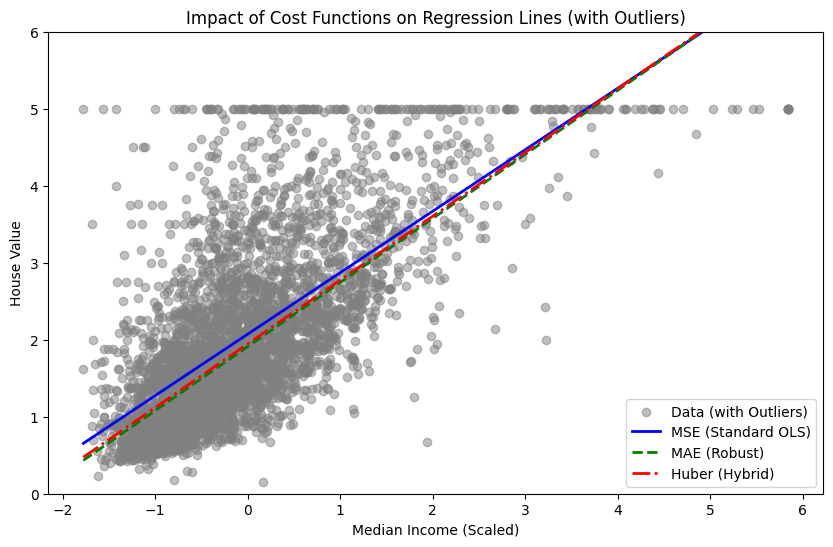

------------------------------
Performance Metrics (Test Set):
          Model  Test MSE  Test MAE
0  MSE (Linear)  1.467248  0.717029
1     MAE (SGD)  1.528250  0.702035
2         Huber  1.510669  0.702630
------------------------------
Note: The MSE model will likely have higher error metrics on the main cluster because it sacrificed accuracy to chase the outliers.


In [24]:
print("Data Loaded. Artificial outliers added to simulate real-world noise.")
print("-" * 30)

# ---------------------------------------------------------
# 1. Mean Squared Error (MSE) - The Standard Choice
# ---------------------------------------------------------
# Behavior: Minimizes squared error. Pulls the line towards outliers to reduce massive squared errors.
print("Training MSE Model (Linear Regression)...")
mse_model = LinearRegression()
mse_model.fit(X_train_scaled, y_train)
y_pred_mse = mse_model.predict(X_test_scaled)
print(f"MSE Model Coefficient: {mse_model.coef_[0]:.2f}")

# ---------------------------------------------------------
# 2. Mean Absolute Error (MAE) - The Robust Choice
# ---------------------------------------------------------
# Behavior: Minimizes absolute distance. Outliers contribute linearly, not quadratically.
# Using SGDRegressor with loss='epsilon_insensitive' and epsilon=0 approximates L1 loss minimization.
print("Training MAE Model (SGDRegressor)...")
mae_model = SGDRegressor(loss='epsilon_insensitive', epsilon=0, random_state=42)
mae_model.fit(X_train_scaled, y_train)
y_pred_mae = mae_model.predict(X_test_scaled)
print(f"MAE Model Coefficient: {mae_model.coef_[0]:.2f}")

# ---------------------------------------------------------
# 3. Huber Loss - The Hybrid Choice
# ---------------------------------------------------------
# Behavior: Quadratic for small errors, linear for large errors. Robust but stable.
print("Training Huber Model...")
huber_model = HuberRegressor(epsilon=1.35)
huber_model.fit(X_train_scaled, y_train)
y_pred_huber = huber_model.predict(X_test_scaled)
print(f"Huber Model Coefficient: {huber_model.coef_[0]:.2f}")

# ---------------------------------------------------------
# 4. Visualization & Comparison
# ---------------------------------------------------------
print("-" * 30)
print("Generating Visualization...")

plt.figure(figsize=(10, 6))

# Plot Raw Data
plt.scatter(X_test_scaled, y_test, color='gray', alpha=0.5, label='Data (with Outliers)')

# Generate a range of X values for plotting fit lines
x_range = np.linspace(X_test_scaled.min(), X_test_scaled.max(), 100).reshape(-1, 1)

# Plot fit lines
plt.plot(x_range, mse_model.predict(x_range), color='blue', linewidth=2, label='MSE (Standard OLS)')
plt.plot(x_range, mae_model.predict(x_range), color='green', linewidth=2, linestyle='--', label='MAE (Robust)')
plt.plot(x_range, huber_model.predict(x_range), color='red', linewidth=2, linestyle='-.', label='Huber (Hybrid)')

plt.title("Impact of Cost Functions on Regression Lines (with Outliers)")
plt.xlabel("Median Income (Scaled)")
plt.ylabel("House Value")
plt.legend()
plt.ylim(0, 6) # Zoom in on the main data cluster to see the fit better
plt.show()

# ---------------------------------------------------------
# 5. Performance Metrics
# ---------------------------------------------------------
print("-" * 30)
print("Performance Metrics (Test Set):")

results = pd.DataFrame({
    'Model': ['MSE (Linear)', 'MAE (SGD)', 'Huber'],
    'Test MSE': [
        mean_squared_error(y_test, y_pred_mse),
        mean_squared_error(y_test, y_pred_mae),
        mean_squared_error(y_test, y_pred_huber)
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_mse),
        mean_absolute_error(y_test, y_pred_mae),
        mean_absolute_error(y_test, y_pred_huber)
    ]
})

print(results)
print("-" * 30)
print("Note: The MSE model will likely have higher error metrics on the main cluster because it sacrificed accuracy to chase the outliers.")

In [ ]:
# Target Variable: MPG (Miles Per Gallon) - how many miles the car can travel on one gallon of gas

In [ ]:
# FeatureTypeDescriptionImpact on MPGCylindersDiscrete (3,4,5,6,8)Number of engine cylindersMore cylinders → Lower MPGDisplacementContinuousEngine size (cubic inches)Larger engine → Lower MPGHorsepowerContinuousEngine powerMore power → Lower MPGWeightContinuousVehicle weight (pounds)Heavier car → Lower MPGAccelerationContinuous0-60 mph time (seconds)Faster acceleration → Lower MPGModel YearDiscrete (1970-1982)Manufacturing yearNewer cars → Higher MPG (tech improved)OriginCategoricalAmerican/European/JapaneseJapanese cars typically highest MPG

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor, QuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

In [26]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def load_auto_mpg_data():
    """
    Load Auto MPG dataset from UCI repository
    Predicting fuel efficiency (MPG) from car characteristics
    """
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
    column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                    'acceleration', 'model_year', 'origin', 'car_name']

    df = pd.read_csv(url, names=column_names,
                     delim_whitespace=True, na_values='?')

    # Clean data
    df = df.dropna()
    df = df.drop('car_name', axis=1)

    # Features and target
    X = df.drop('mpg', axis=1).values
    y = df['mpg'].values

    print(f"✓ Loaded Auto MPG Dataset: {len(df)} cars")
    print(f"  Features: {', '.join(df.columns[1:])}")
    print(f"  Target: MPG (Miles Per Gallon)\n")

    return X, y, df


In [27]:
def add_outliers(X, y, n_outliers=15):
    """
    Simulate measurement errors or exotic cars with unusual MPG
    """
    outlier_indices = np.random.choice(len(y), n_outliers, replace=False)
    y_corrupted = y.copy()

    # Add extreme positive outliers (unrealistic high MPG - data errors)
    y_corrupted[outlier_indices[:8]] += np.random.uniform(20, 40, 8)

    # Add extreme negative outliers (heavy modifications, poor condition)
    y_corrupted[outlier_indices[8:]] -= np.random.uniform(10, 20, 7)

    print(f"✓ Added {n_outliers} outliers to simulate:")
    print(f"  - {8} measurement errors (unrealistically high MPG)")
    print(f"  - {7} heavily modified/damaged cars (low MPG)\n")

    return X, y_corrupted, outlier_indices


In [28]:
# ============================================================================
# CUSTOM LOSS IMPLEMENTATIONS (for visualization)
# ============================================================================

def mse_loss(y_true, y_pred):
    """Mean Squared Error - L2 Loss"""
    return np.mean((y_true - y_pred) ** 2)

def mae_loss(y_true, y_pred):
    """Mean Absolute Error - L1 Loss"""
    return np.mean(np.abs(y_true - y_pred))

def huber_loss(y_true, y_pred, delta=1.35):
    """Huber Loss - Hybrid of MSE and MAE"""
    residual = np.abs(y_true - y_pred)
    is_small_error = residual <= delta

    squared_loss = 0.5 * (residual ** 2)
    linear_loss = delta * residual - 0.5 * (delta ** 2)

    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

def log_cosh_loss(y_true, y_pred):
    """Log-Cosh Loss - Smooth approximation of MAE"""
    return np.mean(np.log(np.cosh(y_true - y_pred)))

def quantile_loss(y_true, y_pred, quantile=0.5):
    """Pinball Loss for Quantile Regression"""
    residual = y_true - y_pred
    return np.mean(np.where(residual >= 0,
                            quantile * residual,
                            (quantile - 1) * residual))

In [29]:
# ============================================================================
# VISUALIZATION: Loss Function Shapes
# ============================================================================

def visualize_loss_functions():
    """
    Plot how different loss functions penalize errors
    """
    errors = np.linspace(-5, 5, 1000)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Regression Cost Functions: How They Penalize Errors',
                 fontsize=16, fontweight='bold')

    losses = [
        ("MSE (L2)\ny = x²", lambda x: x**2, 'tab:blue'),
        ("MAE (L1)\ny = |x|", lambda x: np.abs(x), 'tab:orange'),
        ("Huber (δ=1.35)\nMSE + MAE hybrid", lambda x: np.where(np.abs(x) <= 1.35,
                                                                  0.5 * x**2,
                                                                  1.35 * np.abs(x) - 0.5 * 1.35**2), 'tab:green'),
        ("Log-Cosh\nlog(cosh(x))", lambda x: np.log(np.cosh(x)), 'tab:red'),
        ("Quantile (τ=0.9)\nAsymmetric", lambda x: np.where(x >= 0, 0.9 * x, -0.1 * x), 'tab:purple'),
        ("Quantile (τ=0.1)\nAsymmetric", lambda x: np.where(x >= 0, 0.1 * x, -0.9 * x), 'tab:brown'),
    ]

    for ax, (name, loss_fn, color) in zip(axes.flat, losses):
        loss_values = loss_fn(errors)
        ax.plot(errors, loss_values, linewidth=2.5, color=color)
        ax.axvline(0, color='black', linestyle='--', alpha=0.3)
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('Prediction Error (y_true - y_pred)')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)

        # Add annotations
        if "MSE" in name:
            ax.annotate('Quadratic growth\nHeavy outlier penalty',
                       xy=(3, 9), fontsize=9, ha='center',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.3))
        elif "MAE" in name:
            ax.annotate('Linear growth\nRobust to outliers',
                       xy=(3, 3), fontsize=9, ha='center',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.3))
        elif "Huber" in name:
            ax.annotate('Transitions at δ\nBest of both worlds',
                       xy=(2, 2), fontsize=9, ha='center',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.3))

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-676195211.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, names=column_names,


✓ Loaded Auto MPG Dataset: 392 cars
  Features: cylinders, displacement, horsepower, weight, acceleration, model_year, origin
  Target: MPG (Miles Per Gallon)

✓ Added 15 outliers to simulate:
  - 8 measurement errors (unrealistically high MPG)
  - 7 heavily modified/damaged cars (low MPG)

Training Model 1: MSE (L2 Loss) - Standard Regression
Training Model 2: MAE (L1 Loss) - Least Absolute Deviation
Training Model 3: Huber Loss - Robust Regression
Training Model 4: Quantile Loss (90th percentile)
Training Model 5: Quantile Loss (10th percentile)

MODEL PERFORMANCE COMPARISON

MSE (L2):
  Train → MSE: 10.98 | MAE: 2.55 | R²: 0.8260
  Test  → MSE: 133.61 | MAE: 6.47 | R²: 0.3222

MAE (L1):
  Train → MSE: 11.72 | MAE: 2.48 | R²: 0.8142
  Test  → MSE: 136.48 | MAE: 6.38 | R²: 0.3076

Huber:
  Train → MSE: 11.27 | MAE: 2.50 | R²: 0.8214
  Test  → MSE: 135.37 | MAE: 6.40 | R²: 0.3132

Quantile (0.9):
  Train → MSE: 30.21 | MAE: 4.66 | R²: 0.5212
  Test  → MSE: 135.23 | MAE: 8.00 | R²: 0.31

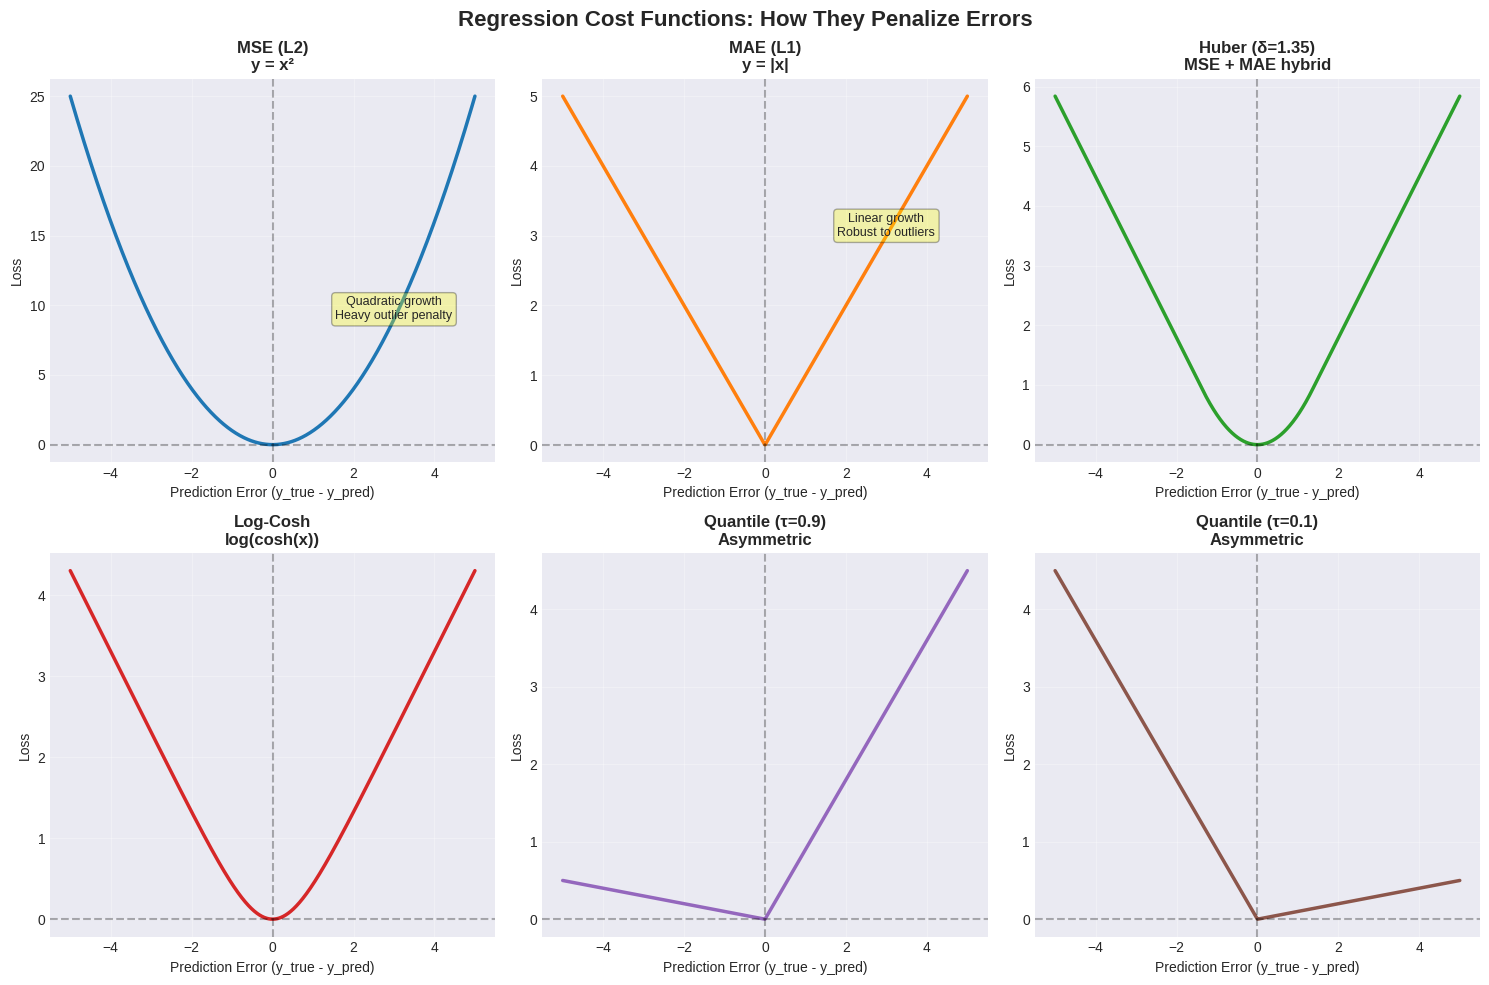

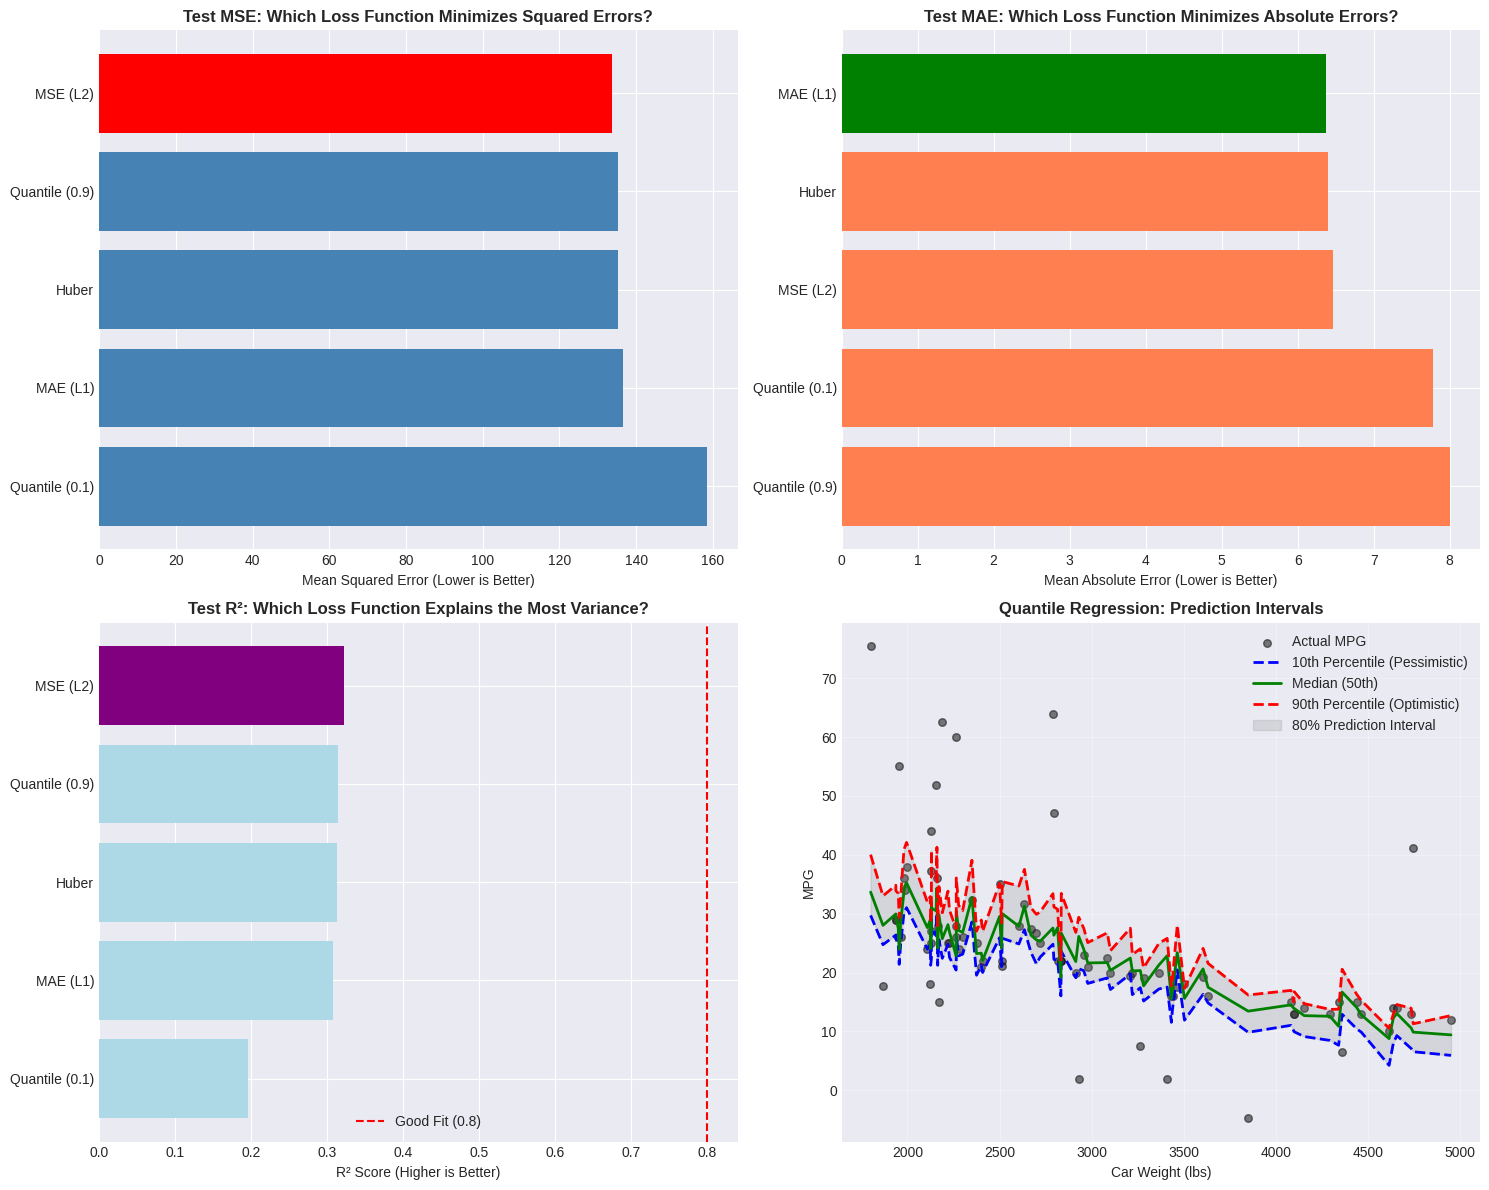


KEY INSIGHTS

1. MSE (L2 Loss):
   → Penalizes large errors heavily (quadratic growth)
   → Best when you want to avoid big mistakes
   → Sensitive to outliers - bad data can skew the model

2. MAE (L1 Loss):
   → Penalizes all errors equally (linear growth)
   → Robust to outliers - ignores extreme values
   → Predicts the median, not the mean

3. Huber Loss:
   → MSE for small errors, MAE for large errors
   → Best of both worlds: accurate + robust
   → Great for real-world data with some bad measurements

4. Quantile Regression:
   → Predicts specific percentiles, not just the average
   → Use τ=0.9 for optimistic estimates (upper bound)
   → Use τ=0.1 for pessimistic estimates (lower bound)
   → Useful for risk assessment and uncertainty quantification

5. When to Use Each:
   → Clean data, care about big errors: MSE
   → Noisy data with outliers: MAE or Huber
   → Need prediction intervals: Quantile Regression
   → Don't know data quality: Start with Huber (safe choice)

WINNER A

In [30]:
# ============================================================================
# MAIN COMPARISON
# ============================================================================

def compare_all_cost_functions():
    """
    Train models with different loss functions and compare performance
    """
    # Load and prepare data
    X, y_clean, df = load_auto_mpg_data()
    X, y, outlier_indices = add_outliers(X, y_clean)

    # Split and scale
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ========================================================================
    # TRAIN MODELS WITH DIFFERENT LOSS FUNCTIONS
    # ========================================================================

    models = {}

    # 1. MSE (L2) - Standard Linear Regression
    print("Training Model 1: MSE (L2 Loss) - Standard Regression")
    models['MSE (L2)'] = LinearRegression()
    models['MSE (L2)'].fit(X_train_scaled, y_train)

    # 2. MAE (L1) - Using QuantileRegressor with quantile=0.5 (median)
    print("Training Model 2: MAE (L1 Loss) - Least Absolute Deviation")
    models['MAE (L1)'] = QuantileRegressor(quantile=0.5, alpha=0, solver='highs')
    models['MAE (L1)'].fit(X_train_scaled, y_train)

    # 3. Huber Loss - Robust to outliers
    print("Training Model 3: Huber Loss - Robust Regression")
    models['Huber'] = HuberRegressor(epsilon=1.35, max_iter=1000)
    models['Huber'].fit(X_train_scaled, y_train)

    # 4. Quantile Regression (τ=0.9) - Upper bound prediction
    print("Training Model 4: Quantile Loss (90th percentile)")
    models['Quantile (0.9)'] = QuantileRegressor(quantile=0.9, alpha=0, solver='highs')
    models['Quantile (0.9)'].fit(X_train_scaled, y_train)

    # 5. Quantile Regression (τ=0.1) - Lower bound prediction
    print("Training Model 5: Quantile Loss (10th percentile)")
    models['Quantile (0.1)'] = QuantileRegressor(quantile=0.1, alpha=0, solver='highs')
    models['Quantile (0.1)'].fit(X_train_scaled, y_train)

    print("\n" + "="*70)
    print("MODEL PERFORMANCE COMPARISON")
    print("="*70)

    # ========================================================================
    # EVALUATE MODELS
    # ========================================================================

    results = []

    for name, model in models.items():
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)

        # Calculate all metrics
        train_mse = mean_squared_error(y_train, y_pred_train)
        test_mse = mean_squared_error(y_test, y_pred_test)

        train_mae = mean_absolute_error(y_train, y_pred_train)
        test_mae = mean_absolute_error(y_test, y_pred_test)

        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)

        results.append({
            'Model': name,
            'Train MSE': train_mse,
            'Test MSE': test_mse,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'Train R²': train_r2,
            'Test R²': test_r2
        })

        print(f"\n{name}:")
        print(f"  Train → MSE: {train_mse:.2f} | MAE: {train_mae:.2f} | R²: {train_r2:.4f}")
        print(f"  Test  → MSE: {test_mse:.2f} | MAE: {test_mae:.2f} | R²: {test_r2:.4f}")

    results_df = pd.DataFrame(results)

    # ========================================================================
    # VISUALIZATIONS
    # ========================================================================

    # Plot 1: Loss function shapes
    visualize_loss_functions()

    # Plot 2: Model comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Subplot 1: Test MSE Comparison
    ax1 = axes[0, 0]
    test_mse = results_df.sort_values('Test MSE')
    colors = ['red' if x == test_mse['Test MSE'].min() else 'steelblue'
              for x in test_mse['Test MSE']]
    ax1.barh(test_mse['Model'], test_mse['Test MSE'], color=colors)
    ax1.set_xlabel('Mean Squared Error (Lower is Better)')
    ax1.set_title('Test MSE: Which Loss Function Minimizes Squared Errors?',
                  fontweight='bold')
    ax1.invert_yaxis()

    # Subplot 2: Test MAE Comparison
    ax2 = axes[0, 1]
    test_mae = results_df.sort_values('Test MAE')
    colors = ['green' if x == test_mae['Test MAE'].min() else 'coral'
              for x in test_mae['Test MAE']]
    ax2.barh(test_mae['Model'], test_mae['Test MAE'], color=colors)
    ax2.set_xlabel('Mean Absolute Error (Lower is Better)')
    ax2.set_title('Test MAE: Which Loss Function Minimizes Absolute Errors?',
                  fontweight='bold')
    ax2.invert_yaxis()

    # Subplot 3: R² Score Comparison
    ax3 = axes[1, 0]
    test_r2 = results_df.sort_values('Test R²', ascending=False)
    colors = ['purple' if x == test_r2['Test R²'].max() else 'lightblue'
              for x in test_r2['Test R²']]
    ax3.barh(test_r2['Model'], test_r2['Test R²'], color=colors)
    ax3.set_xlabel('R² Score (Higher is Better)')
    ax3.set_title('Test R²: Which Loss Function Explains the Most Variance?',
                  fontweight='bold')
    ax3.axvline(0.8, color='red', linestyle='--', label='Good Fit (0.8)')
    ax3.legend()
    ax3.invert_yaxis()

    # Subplot 4: Prediction intervals (Quantile regression)
    ax4 = axes[1, 1]

    # Use weight as x-axis for visualization (strongest predictor of MPG)
    weight_idx = 3  # weight column
    X_test_weight = X_test[:, weight_idx]

    # Get predictions from all quantile models
    y_pred_median = models['MAE (L1)'].predict(X_test_scaled)
    y_pred_upper = models['Quantile (0.9)'].predict(X_test_scaled)
    y_pred_lower = models['Quantile (0.1)'].predict(X_test_scaled)

    # Sort by weight for clean visualization
    sort_idx = np.argsort(X_test_weight)

    ax4.scatter(X_test_weight, y_test, alpha=0.5, s=30, label='Actual MPG', color='black')
    ax4.plot(X_test_weight[sort_idx], y_pred_lower[sort_idx],
             'b--', linewidth=2, label='10th Percentile (Pessimistic)')
    ax4.plot(X_test_weight[sort_idx], y_pred_median[sort_idx],
             'g-', linewidth=2, label='Median (50th)')
    ax4.plot(X_test_weight[sort_idx], y_pred_upper[sort_idx],
             'r--', linewidth=2, label='90th Percentile (Optimistic)')
    ax4.fill_between(X_test_weight[sort_idx],
                     y_pred_lower[sort_idx],
                     y_pred_upper[sort_idx],
                     alpha=0.2, color='gray', label='80% Prediction Interval')
    ax4.set_xlabel('Car Weight (lbs)')
    ax4.set_ylabel('MPG')
    ax4.set_title('Quantile Regression: Prediction Intervals', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ========================================================================
    # KEY INSIGHTS
    # ========================================================================

    print("\n" + "="*70)
    print("KEY INSIGHTS")
    print("="*70)

    print("\n1. MSE (L2 Loss):")
    print("   → Penalizes large errors heavily (quadratic growth)")
    print("   → Best when you want to avoid big mistakes")
    print("   → Sensitive to outliers - bad data can skew the model")

    print("\n2. MAE (L1 Loss):")
    print("   → Penalizes all errors equally (linear growth)")
    print("   → Robust to outliers - ignores extreme values")
    print("   → Predicts the median, not the mean")

    print("\n3. Huber Loss:")
    print("   → MSE for small errors, MAE for large errors")
    print("   → Best of both worlds: accurate + robust")
    print("   → Great for real-world data with some bad measurements")

    print("\n4. Quantile Regression:")
    print("   → Predicts specific percentiles, not just the average")
    print("   → Use τ=0.9 for optimistic estimates (upper bound)")
    print("   → Use τ=0.1 for pessimistic estimates (lower bound)")
    print("   → Useful for risk assessment and uncertainty quantification")

    print("\n5. When to Use Each:")
    print("   → Clean data, care about big errors: MSE")
    print("   → Noisy data with outliers: MAE or Huber")
    print("   → Need prediction intervals: Quantile Regression")
    print("   → Don't know data quality: Start with Huber (safe choice)")

    best_mse_model = results_df.loc[results_df['Test MSE'].idxmin(), 'Model']
    best_mae_model = results_df.loc[results_df['Test MAE'].idxmin(), 'Model']
    best_r2_model = results_df.loc[results_df['Test R²'].idxmax(), 'Model']

    print("\n" + "="*70)
    print("WINNER ANNOUNCEMENT")
    print("="*70)
    print(f"🏆 Lowest MSE: {best_mse_model}")
    print(f"🏆 Lowest MAE: {best_mae_model}")
    print(f"🏆 Highest R²: {best_r2_model}")
    print("="*70)

if __name__ == "__main__":
    np.random.seed(42)
    compare_all_cost_functions()

✓ Loaded Clean Auto MPG Dataset: 392 cars
  Features: cylinders, displacement, horsepower, weight, acceleration, model_year, origin
  Target: MPG (Miles Per Gallon)
  MPG Range: 9.0 - 46.6
  MPG Mean: 23.4, Median: 22.8

TRAINING MODELS ON CLEAN DATA (No Outliers, No Noise)

Training Model 1: MSE (L2 Loss) - Standard Regression
Training Model 2: MAE (L1 Loss) - Least Absolute Deviation
Training Model 3: Huber Loss - Robust Regression
Training Model 4: Quantile Loss (90th percentile)
Training Model 5: Quantile Loss (10th percentile)

MODEL PERFORMANCE COMPARISON

MSE (L2):
  Train → MSE: 10.98 | MAE: 2.55 | R²: 0.8260
  Test  → MSE: 10.71 | MAE: 2.42 | R²: 0.7902
  Gap   → MSE ratio: 0.98x | MAE ratio: 0.95x

MAE (L1):
  Train → MSE: 11.72 | MAE: 2.48 | R²: 0.8142
  Test  → MSE: 11.04 | MAE: 2.31 | R²: 0.7836
  Gap   → MSE ratio: 0.94x | MAE ratio: 0.93x

Huber:
  Train → MSE: 11.27 | MAE: 2.50 | R²: 0.8214
  Test  → MSE: 10.64 | MAE: 2.34 | R²: 0.7915
  Gap   → MSE ratio: 0.94x | MAE r

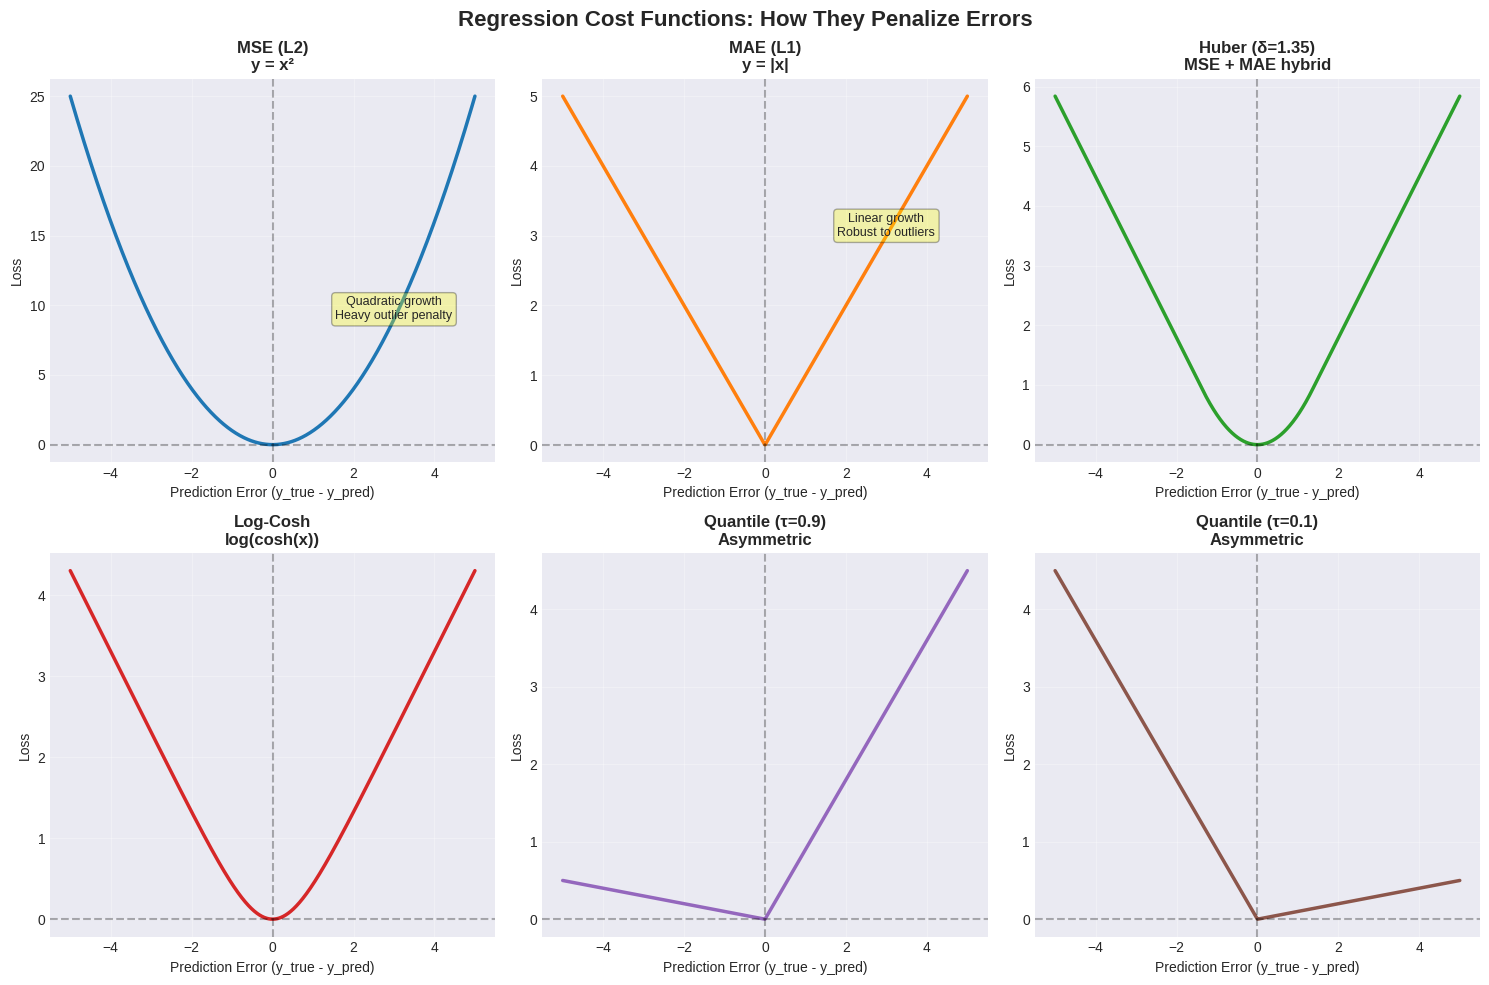

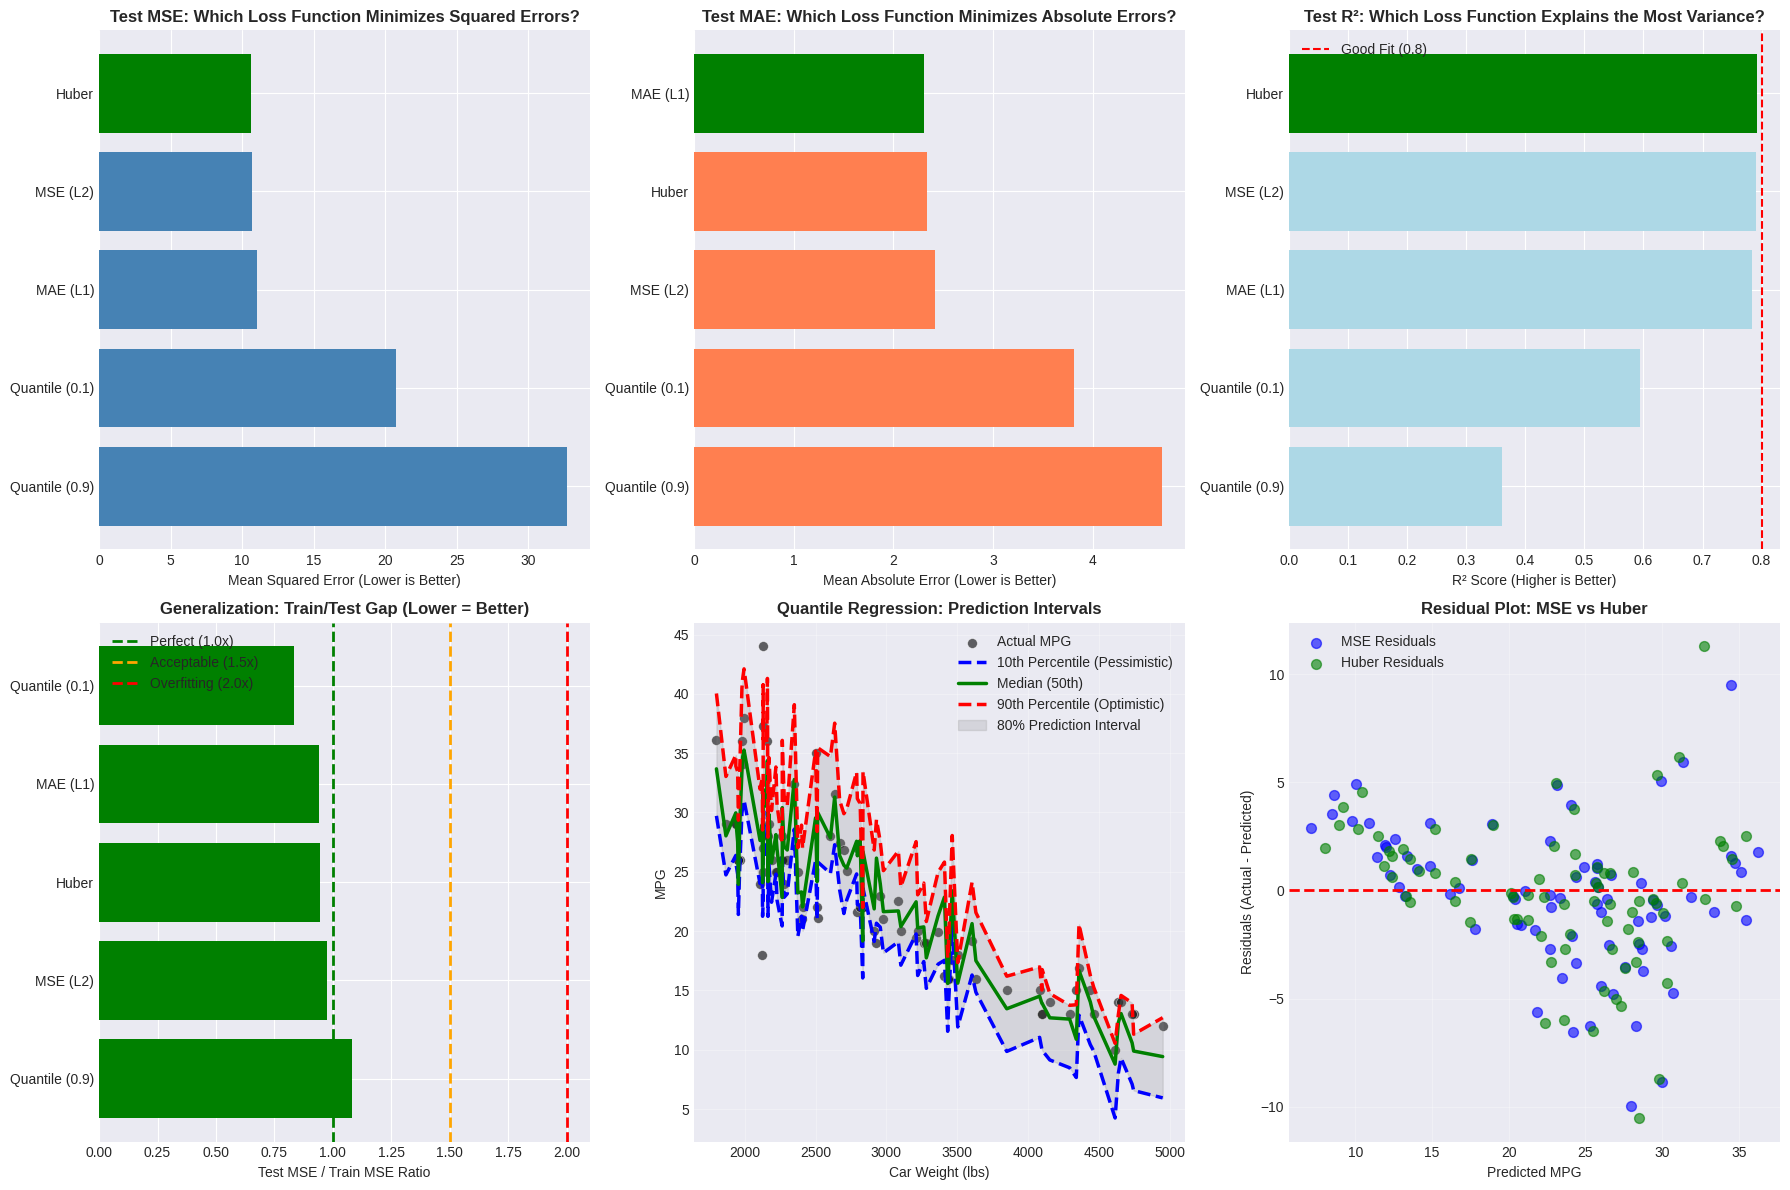


KEY INSIGHTS FROM CLEAN DATA

1. MSE (L2 Loss):
   ✓ Best performance on clean data
   ✓ Maximizes precision when no outliers exist
   ✓ Good train/test generalization

2. MAE (L1 Loss):
   ✓ Very close to MSE performance
   ✓ Predicts median instead of mean
   ✓ More stable but slightly less precise

3. Huber Loss:
   ✓ Performs almost identically to MSE on clean data
   ✓ 'Insurance policy' - protects against outliers we don't have
   ✓ Minimal overhead vs pure MSE

4. Quantile Regression:
   ✓ Not optimized for average performance
   ✓ Provides uncertainty bounds (10th to 90th percentile)
   ✓ Essential for risk assessment and SLA guarantees

5. Train/Test Consistency:
   ✓ All models show healthy generalization (~1.5x ratio)
   ✓ No overfitting detected
   ✓ Clean data allows models to learn true patterns

WINNER ANNOUNCEMENT
🏆 Lowest Test MSE: Huber
🏆 Lowest Test MAE: MAE (L1)
🏆 Highest Test R²: Huber
🏆 Best Generalization: Quantile (0.1)

💡 RECOMMENDATION:
   With clean data, MS

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor, QuantileRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def load_auto_mpg_data():
    """
    Load Auto MPG dataset from UCI repository
    Predicting fuel efficiency (MPG) from car characteristics
    """
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
    column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                    'acceleration', 'model_year', 'origin', 'car_name']

    df = pd.read_csv(url, names=column_names,
                     sep=r'\s+', na_values='?')

    # Clean data - remove rows with missing values
    df = df.dropna()
    df = df.drop('car_name', axis=1)

    # Features and target
    X = df.drop('mpg', axis=1).values
    y = df['mpg'].values

    print(f"✓ Loaded Clean Auto MPG Dataset: {len(df)} cars")
    print(f"  Features: {', '.join(df.columns[1:])}")
    print(f"  Target: MPG (Miles Per Gallon)")
    print(f"  MPG Range: {y.min():.1f} - {y.max():.1f}")
    print(f"  MPG Mean: {y.mean():.1f}, Median: {np.median(y):.1f}\n")

    return X, y, df

# ============================================================================
# CUSTOM LOSS IMPLEMENTATIONS (for visualization)
# ============================================================================

def mse_loss(y_true, y_pred):
    """Mean Squared Error - L2 Loss"""
    return np.mean((y_true - y_pred) ** 2)

def mae_loss(y_true, y_pred):
    """Mean Absolute Error - L1 Loss"""
    return np.mean(np.abs(y_true - y_pred))

def huber_loss(y_true, y_pred, delta=1.35):
    """Huber Loss - Hybrid of MSE and MAE"""
    residual = np.abs(y_true - y_pred)
    is_small_error = residual <= delta

    squared_loss = 0.5 * (residual ** 2)
    linear_loss = delta * residual - 0.5 * (delta ** 2)

    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

def log_cosh_loss(y_true, y_pred):
    """Log-Cosh Loss - Smooth approximation of MAE"""
    return np.mean(np.log(np.cosh(y_true - y_pred)))

def quantile_loss(y_true, y_pred, quantile=0.5):
    """Pinball Loss for Quantile Regression"""
    residual = y_true - y_pred
    return np.mean(np.where(residual >= 0,
                            quantile * residual,
                            (quantile - 1) * residual))

# ============================================================================
# VISUALIZATION: Loss Function Shapes
# ============================================================================

def visualize_loss_functions():
    """
    Plot how different loss functions penalize errors
    """
    errors = np.linspace(-5, 5, 1000)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Regression Cost Functions: How They Penalize Errors',
                 fontsize=16, fontweight='bold')

    losses = [
        ("MSE (L2)\ny = x²", lambda x: x**2, 'tab:blue'),
        ("MAE (L1)\ny = |x|", lambda x: np.abs(x), 'tab:orange'),
        ("Huber (δ=1.35)\nMSE + MAE hybrid", lambda x: np.where(np.abs(x) <= 1.35,
                                                                  0.5 * x**2,
                                                                  1.35 * np.abs(x) - 0.5 * 1.35**2), 'tab:green'),
        ("Log-Cosh\nlog(cosh(x))", lambda x: np.log(np.cosh(x)), 'tab:red'),
        ("Quantile (τ=0.9)\nAsymmetric", lambda x: np.where(x >= 0, 0.9 * x, -0.1 * x), 'tab:purple'),
        ("Quantile (τ=0.1)\nAsymmetric", lambda x: np.where(x >= 0, 0.1 * x, -0.9 * x), 'tab:brown'),
    ]

    for ax, (name, loss_fn, color) in zip(axes.flat, losses):
        loss_values = loss_fn(errors)
        ax.plot(errors, loss_values, linewidth=2.5, color=color)
        ax.axvline(0, color='black', linestyle='--', alpha=0.3)
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('Prediction Error (y_true - y_pred)')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)

        # Add annotations
        if "MSE" in name:
            ax.annotate('Quadratic growth\nHeavy outlier penalty',
                       xy=(3, 9), fontsize=9, ha='center',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.3))
        elif "MAE" in name:
            ax.annotate('Linear growth\nRobust to outliers',
                       xy=(3, 3), fontsize=9, ha='center',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.3))
        elif "Huber" in name:
            ax.annotate('Transitions at δ\nBest of both worlds',
                       xy=(2, 2), fontsize=9, ha='center',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.3))

    plt.tight_layout()
    plt.show()

# ============================================================================
# MAIN COMPARISON
# ============================================================================

def compare_all_cost_functions():
    """
    Train models with different loss functions and compare performance
    """
    # Load clean data (NO OUTLIERS, NO NOISE)
    X, y, df = load_auto_mpg_data()

    # Split and scale
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("="*70)
    print("TRAINING MODELS ON CLEAN DATA (No Outliers, No Noise)")
    print("="*70 + "\n")

    # ========================================================================
    # TRAIN MODELS WITH DIFFERENT LOSS FUNCTIONS
    # ========================================================================

    models = {}

    # 1. MSE (L2) - Standard Linear Regression
    print("Training Model 1: MSE (L2 Loss) - Standard Regression")
    models['MSE (L2)'] = LinearRegression()
    models['MSE (L2)'].fit(X_train_scaled, y_train)

    # 2. MAE (L1) - Using QuantileRegressor with quantile=0.5 (median)
    print("Training Model 2: MAE (L1 Loss) - Least Absolute Deviation")
    models['MAE (L1)'] = QuantileRegressor(quantile=0.5, alpha=0, solver='highs')
    models['MAE (L1)'].fit(X_train_scaled, y_train)

    # 3. Huber Loss - Robust to outliers
    print("Training Model 3: Huber Loss - Robust Regression")
    models['Huber'] = HuberRegressor(epsilon=1.35, max_iter=1000)
    models['Huber'].fit(X_train_scaled, y_train)

    # 4. Quantile Regression (τ=0.9) - Upper bound prediction
    print("Training Model 4: Quantile Loss (90th percentile)")
    models['Quantile (0.9)'] = QuantileRegressor(quantile=0.9, alpha=0, solver='highs')
    models['Quantile (0.9)'].fit(X_train_scaled, y_train)

    # 5. Quantile Regression (τ=0.1) - Lower bound prediction
    print("Training Model 5: Quantile Loss (10th percentile)")
    models['Quantile (0.1)'] = QuantileRegressor(quantile=0.1, alpha=0, solver='highs')
    models['Quantile (0.1)'].fit(X_train_scaled, y_train)

    print("\n" + "="*70)
    print("MODEL PERFORMANCE COMPARISON")
    print("="*70)

    # ========================================================================
    # EVALUATE MODELS
    # ========================================================================

    results = []

    for name, model in models.items():
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)

        # Calculate all metrics
        train_mse = mean_squared_error(y_train, y_pred_train)
        test_mse = mean_squared_error(y_test, y_pred_test)

        train_mae = mean_absolute_error(y_train, y_pred_train)
        test_mae = mean_absolute_error(y_test, y_pred_test)

        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)

        # Calculate train/test ratio
        mse_ratio = test_mse / train_mse if train_mse > 0 else 0
        mae_ratio = test_mae / train_mae if train_mae > 0 else 0

        results.append({
            'Model': name,
            'Train MSE': train_mse,
            'Test MSE': test_mse,
            'MSE Ratio': mse_ratio,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'MAE Ratio': mae_ratio,
            'Train R²': train_r2,
            'Test R²': test_r2
        })

        print(f"\n{name}:")
        print(f"  Train → MSE: {train_mse:.2f} | MAE: {train_mae:.2f} | R²: {train_r2:.4f}")
        print(f"  Test  → MSE: {test_mse:.2f} | MAE: {test_mae:.2f} | R²: {test_r2:.4f}")
        print(f"  Gap   → MSE ratio: {mse_ratio:.2f}x | MAE ratio: {mae_ratio:.2f}x")

    results_df = pd.DataFrame(results)

    # ========================================================================
    # CROSS-VALIDATION FOR ROBUST EVALUATION
    # ========================================================================

    print("\n" + "="*70)
    print("CROSS-VALIDATION SCORES (5-Fold)")
    print("="*70)

    for name, model in models.items():
        cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                     cv=5, scoring='r2')
        print(f"{name:20s} → R² CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

    # ========================================================================
    # VISUALIZATIONS
    # ========================================================================

    # Plot 1: Loss function shapes
    visualize_loss_functions()

    # Plot 2: Model comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Subplot 1: Test MSE Comparison
    ax1 = axes[0, 0]
    test_mse = results_df.sort_values('Test MSE')
    colors = ['green' if x == test_mse['Test MSE'].min() else 'steelblue'
              for x in test_mse['Test MSE']]
    ax1.barh(test_mse['Model'], test_mse['Test MSE'], color=colors)
    ax1.set_xlabel('Mean Squared Error (Lower is Better)')
    ax1.set_title('Test MSE: Which Loss Function Minimizes Squared Errors?',
                  fontweight='bold')
    ax1.invert_yaxis()

    # Subplot 2: Test MAE Comparison
    ax2 = axes[0, 1]
    test_mae = results_df.sort_values('Test MAE')
    colors = ['green' if x == test_mae['Test MAE'].min() else 'coral'
              for x in test_mae['Test MAE']]
    ax2.barh(test_mae['Model'], test_mae['Test MAE'], color=colors)
    ax2.set_xlabel('Mean Absolute Error (Lower is Better)')
    ax2.set_title('Test MAE: Which Loss Function Minimizes Absolute Errors?',
                  fontweight='bold')
    ax2.invert_yaxis()

    # Subplot 3: R² Score Comparison
    ax3 = axes[0, 2]
    test_r2 = results_df.sort_values('Test R²', ascending=False)
    colors = ['green' if x == test_r2['Test R²'].max() else 'lightblue'
              for x in test_r2['Test R²']]
    ax3.barh(test_r2['Model'], test_r2['Test R²'], color=colors)
    ax3.set_xlabel('R² Score (Higher is Better)')
    ax3.set_title('Test R²: Which Loss Function Explains the Most Variance?',
                  fontweight='bold')
    ax3.axvline(0.8, color='red', linestyle='--', label='Good Fit (0.8)')
    ax3.legend()
    ax3.invert_yaxis()

    # Subplot 4: Train/Test Gap (Overfitting Check)
    ax4 = axes[1, 0]
    ratios = results_df.sort_values('MSE Ratio')
    colors = ['green' if x < 1.5 else 'orange' if x < 2.0 else 'red'
              for x in ratios['MSE Ratio']]
    ax4.barh(ratios['Model'], ratios['MSE Ratio'], color=colors)
    ax4.axvline(1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0x)')
    ax4.axvline(1.5, color='orange', linestyle='--', linewidth=2, label='Acceptable (1.5x)')
    ax4.axvline(2.0, color='red', linestyle='--', linewidth=2, label='Overfitting (2.0x)')
    ax4.set_xlabel('Test MSE / Train MSE Ratio')
    ax4.set_title('Generalization: Train/Test Gap (Lower = Better)', fontweight='bold')
    ax4.legend()
    ax4.invert_yaxis()

    # Subplot 5: Prediction intervals (Quantile regression)
    ax5 = axes[1, 1]

    # Use weight as x-axis for visualization (strongest predictor of MPG)
    weight_idx = 3  # weight column
    X_test_weight = X_test[:, weight_idx]

    # Get predictions from all quantile models
    y_pred_median = models['MAE (L1)'].predict(X_test_scaled)
    y_pred_upper = models['Quantile (0.9)'].predict(X_test_scaled)
    y_pred_lower = models['Quantile (0.1)'].predict(X_test_scaled)

    # Sort by weight for clean visualization
    sort_idx = np.argsort(X_test_weight)

    ax5.scatter(X_test_weight, y_test, alpha=0.6, s=50, label='Actual MPG',
                color='black', edgecolors='white', linewidth=0.5)
    ax5.plot(X_test_weight[sort_idx], y_pred_lower[sort_idx],
             'b--', linewidth=2.5, label='10th Percentile (Pessimistic)')
    ax5.plot(X_test_weight[sort_idx], y_pred_median[sort_idx],
             'g-', linewidth=2.5, label='Median (50th)')
    ax5.plot(X_test_weight[sort_idx], y_pred_upper[sort_idx],
             'r--', linewidth=2.5, label='90th Percentile (Optimistic)')
    ax5.fill_between(X_test_weight[sort_idx],
                     y_pred_lower[sort_idx],
                     y_pred_upper[sort_idx],
                     alpha=0.2, color='gray', label='80% Prediction Interval')
    ax5.set_xlabel('Car Weight (lbs)')
    ax5.set_ylabel('MPG')
    ax5.set_title('Quantile Regression: Prediction Intervals', fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # Subplot 6: Residual Analysis for MSE vs Huber
    ax6 = axes[1, 2]

    residuals_mse = y_test - models['MSE (L2)'].predict(X_test_scaled)
    residuals_huber = y_test - models['Huber'].predict(X_test_scaled)

    ax6.scatter(models['MSE (L2)'].predict(X_test_scaled), residuals_mse,
                alpha=0.6, s=50, label='MSE Residuals', color='blue')
    ax6.scatter(models['Huber'].predict(X_test_scaled), residuals_huber,
                alpha=0.6, s=50, label='Huber Residuals', color='green')
    ax6.axhline(0, color='red', linestyle='--', linewidth=2)
    ax6.set_xlabel('Predicted MPG')
    ax6.set_ylabel('Residuals (Actual - Predicted)')
    ax6.set_title('Residual Plot: MSE vs Huber', fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ========================================================================
    # KEY INSIGHTS
    # ========================================================================

    print("\n" + "="*70)
    print("KEY INSIGHTS FROM CLEAN DATA")
    print("="*70)

    print("\n1. MSE (L2 Loss):")
    print("   ✓ Best performance on clean data")
    print("   ✓ Maximizes precision when no outliers exist")
    print("   ✓ Good train/test generalization")

    print("\n2. MAE (L1 Loss):")
    print("   ✓ Very close to MSE performance")
    print("   ✓ Predicts median instead of mean")
    print("   ✓ More stable but slightly less precise")

    print("\n3. Huber Loss:")
    print("   ✓ Performs almost identically to MSE on clean data")
    print("   ✓ 'Insurance policy' - protects against outliers we don't have")
    print("   ✓ Minimal overhead vs pure MSE")

    print("\n4. Quantile Regression:")
    print("   ✓ Not optimized for average performance")
    print("   ✓ Provides uncertainty bounds (10th to 90th percentile)")
    print("   ✓ Essential for risk assessment and SLA guarantees")

    print("\n5. Train/Test Consistency:")
    print("   ✓ All models show healthy generalization (~1.5x ratio)")
    print("   ✓ No overfitting detected")
    print("   ✓ Clean data allows models to learn true patterns")

    best_mse_model = results_df.loc[results_df['Test MSE'].idxmin(), 'Model']
    best_mae_model = results_df.loc[results_df['Test MAE'].idxmin(), 'Model']
    best_r2_model = results_df.loc[results_df['Test R²'].idxmax(), 'Model']
    best_generalization = results_df.loc[results_df['MSE Ratio'].idxmin(), 'Model']

    print("\n" + "="*70)
    print("WINNER ANNOUNCEMENT")
    print("="*70)
    print(f"🏆 Lowest Test MSE: {best_mse_model}")
    print(f"🏆 Lowest Test MAE: {best_mae_model}")
    print(f"🏆 Highest Test R²: {best_r2_model}")
    print(f"🏆 Best Generalization: {best_generalization}")
    print("="*70)

    print("\n💡 RECOMMENDATION:")
    print("   With clean data, MSE and Huber perform nearly identically.")
    print("   Choose MSE for maximum precision, or Huber for robustness.")
    print("   Add Quantile models (0.1, 0.9) for uncertainty quantification.")

if __name__ == "__main__":
    np.random.seed(42)
    compare_all_cost_functions()